# 05 - Backtest
Simulate actual trading with spread + slippage

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import os
from dotenv import load_dotenv
load_dotenv()
import MetaTrader5 as mt5

mt5.initialize()
login = int(os.getenv('MT5_LOGIN', '0'))
password = os.getenv('MT5_PASSWORD')
server = os.getenv('MT5_SERVER', '').strip()
mt5.login(login, password=password, server=server)

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

print('Ready')

Ready


## 1. Fetch H4 + Create Features + Target

In [2]:
symbol = 'EURUSD'
rates = mt5.copy_rates_from_pos(symbol, mt5.TIMEFRAME_H4, 0, 4500)
mt5.shutdown()

df = pd.DataFrame(rates)
df['time'] = pd.to_datetime(df['time'], unit='s')
df = df.set_index('time')

# Features
df['sma_10'] = df['close'].rolling(10).mean()
df['sma_20'] = df['close'].rolling(20).mean()
df['sma_50'] = df['close'].rolling(50).mean()
df['ema_12'] = df['close'].ewm(span=12, adjust=False).mean()
df['ema_26'] = df['close'].ewm(span=26, adjust=False).mean()
df['pct_from_sma20'] = (df['close'] - df['sma_20']) / df['sma_20'] * 100
df['pct_from_sma50'] = (df['close'] - df['sma_50']) / df['sma_50'] * 100

delta = df['close'].diff()
gain = delta.clip(lower=0); loss = -delta.clip(upper=0)
avg_gain = gain.ewm(span=14, adjust=False).mean()
avg_loss = loss.ewm(span=14, adjust=False).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df['rsi'] = 100 - (100 / (1 + rs))

ema12 = df['close'].ewm(span=12, adjust=False).mean()
ema26 = df['close'].ewm(span=26, adjust=False).mean()
df['macd'] = ema12 - ema26
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist'] = df['macd'] - df['macd_signal']

bb_mid = df['close'].rolling(20).mean()
bb_std = df['close'].rolling(20).std()
df['bb_upper'] = bb_mid + (2 * bb_std)
df['bb_lower'] = bb_mid - (2 * bb_std)
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / bb_mid * 100

df['atr'] = (pd.concat([
    df['high'] - df['low'],
    (df['high'] - df['close'].shift()).abs(),
    (df['low'] - df['close'].shift()).abs()
], axis=1).max(axis=1)).rolling(14).mean()

df['return_1'] = df['close'].pct_change(1)
df['return_5'] = df['close'].pct_change(5)
df['range_pct'] = (df['high'] - df['low']) / df['close'] * 100
df['volume_ma'] = df['tick_volume'].rolling(20).mean()
df['volume_ratio'] = df['tick_volume'] / df['volume_ma'].replace(0, np.nan)
df['close_lag1'] = df['close'].shift(1)
df['close_lag2'] = df['close'].shift(2)

feature_cols = [c for c in df.columns if c not in ['time','open','high','low','tick_volume','spread','real_volume']]

print(f'Features: {len(feature_cols)}')

Features: 23


## 2. Walk-Forward Backtest
Train on past 6 months, predict next month, repeat

In [3]:
TP_PIPS = 0.0040
SL_PIPS = 0.0020
SPREAD = 0.0001  # 1 pip spread

results = []
window = 1000  # ~6 months of H4
step = 168     # ~1 month

print(f'Running walk-forward backtest...')
print(f'Window: {window} bars | Step: {step} bars')

for start in range(0, len(df) - window - step, step):
    train_df = df.iloc[start:start+window]
    test_df = df.iloc[start+window:start+window+step]

    # Target for training
    targets = []
    for i in range(len(train_df) - 24):
        entry = train_df['close'].iloc[i]
        tp = entry + TP_PIPS; sl = entry - SL_PIPS
        fh = train_df['high'].iloc[i+1:i+25]; fl = train_df['low'].iloc[i+1:i+25]
        tp_hit = (fh >= tp).any(); sl_hit = (fl <= sl).any()
        if tp_hit and not sl_hit: targets.append(1)
        elif sl_hit and not tp_hit: targets.append(0)
        else: targets.append(-1)

    train = train_df.iloc[:len(targets)].copy()
    train['Target'] = targets
    train = train[train['Target'] != -1].dropna(subset=feature_cols)

    if len(train) < 100:
        continue

    X_tr = train[feature_cols]; y_tr = train['Target']

    model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                          scale_pos_weight=(y_tr==0).sum()/(y_tr==1).sum(),
                          random_state=42, n_jobs=-1, verbosity=0)
    model.fit(X_tr, y_tr)

    # Trade each candle in test period
    for i in range(len(test_df)):
        row = test_df.iloc[i]
        features = row[feature_cols]
        if features.isna().any():
            continue

        pred = model.predict([features])[0]
        if pred == 0:  # predict LOSS = no trade
            continue

        entry = row['close']
        tp = entry + TP_PIPS
        sl = entry - SL_PIPS

        future = df.loc[row.name:]
        if len(future) < 2:
            continue

        future_highs = future['high'].iloc[1:25].max()
        future_lows = future['low'].iloc[1:25].min()

        gross_tp = TP_PIPS
        gross_sl = -SL_PIPS

        if future_highs >= tp and future_lows <= sl:
            # Both hit — use earliest
            tp_idx = (future['high'].iloc[1:25] >= tp).idxmax()
            sl_idx = (future['low'].iloc[1:25] <= sl).idxmax()
            pnl = gross_tp if tp_idx < sl_idx else gross_sl
        elif future_highs >= tp:
            pnl = gross_tp
        elif future_lows <= sl:
            pnl = gross_sl
        else:
            # Neither hit in 24 candles — close at last price
            exit_price = future['close'].iloc[24]
            pnl = (exit_price - entry) / entry

        pnl -= SPREAD  # subtract spread

        results.append({
            'time': row.name,
            'entry': entry,
            'pred': pred,
            'pnl': pnl
        })

print(f'Done! {len(results)} trades executed')

Running walk-forward backtest...
Window: 1000 bars | Step: 168 bars
Done! 1275 trades executed


## 3. Performance Summary

In [4]:
bt = pd.DataFrame(results)
bt['cumulative'] = (1 + bt['pnl']).cumprod()

total_trades = len(bt)
wins = (bt['pnl'] > 0).sum()
losses = (bt['pnl'] <= 0).sum()
win_rate = wins / total_trades * 100 if total_trades > 0 else 0
total_return = (bt['cumulative'].iloc[-1] - 1) * 100 if total_trades > 0 else 0
avg_win = bt[bt['pnl'] > 0]['pnl'].mean() * 100 if wins > 0 else 0
avg_loss = bt[bt['pnl'] <= 0]['pnl'].mean() * 100 if losses > 0 else 0
profit_factor = abs(bt[bt['pnl'] > 0]['pnl'].sum() / bt[bt['pnl'] < 0]['pnl'].sum()) if losses > 0 and bt[bt['pnl'] < 0]['pnl'].sum() != 0 else 0
max_dd = (bt['cumulative'].cummax() - bt['cumulative']).max() * 100

print(f"{'='*50}")
print(f"{'BACKTEST RESULTS':^50}")
print(f"{'='*50}")
print(f"Total Trades:  {total_trades}")
print(f"Win Rate:      {win_rate:.1f}%")
print(f"Wins:          {wins}")
print(f"Losses:        {losses}")
print(f"{'='*50}")
print(f"Total Return:  {total_return:+.2f}%")
print(f"Avg Win:       {avg_win:+.2f}%")
print(f"Avg Loss:      {avg_loss:+.2f}%")
print(f"Profit Factor: {profit_factor:.2f}")
print(f"Max Drawdown:  {max_dd:.2f}%")
print(f"{'='*50}")

                 BACKTEST RESULTS                 
Total Trades:  1275
Win Rate:      34.3%
Wins:          437
Losses:        838
Total Return:  -6.55%
Avg Win:       +0.39%
Avg Loss:      -0.21%
Profit Factor: 0.96
Max Drawdown:  32.47%


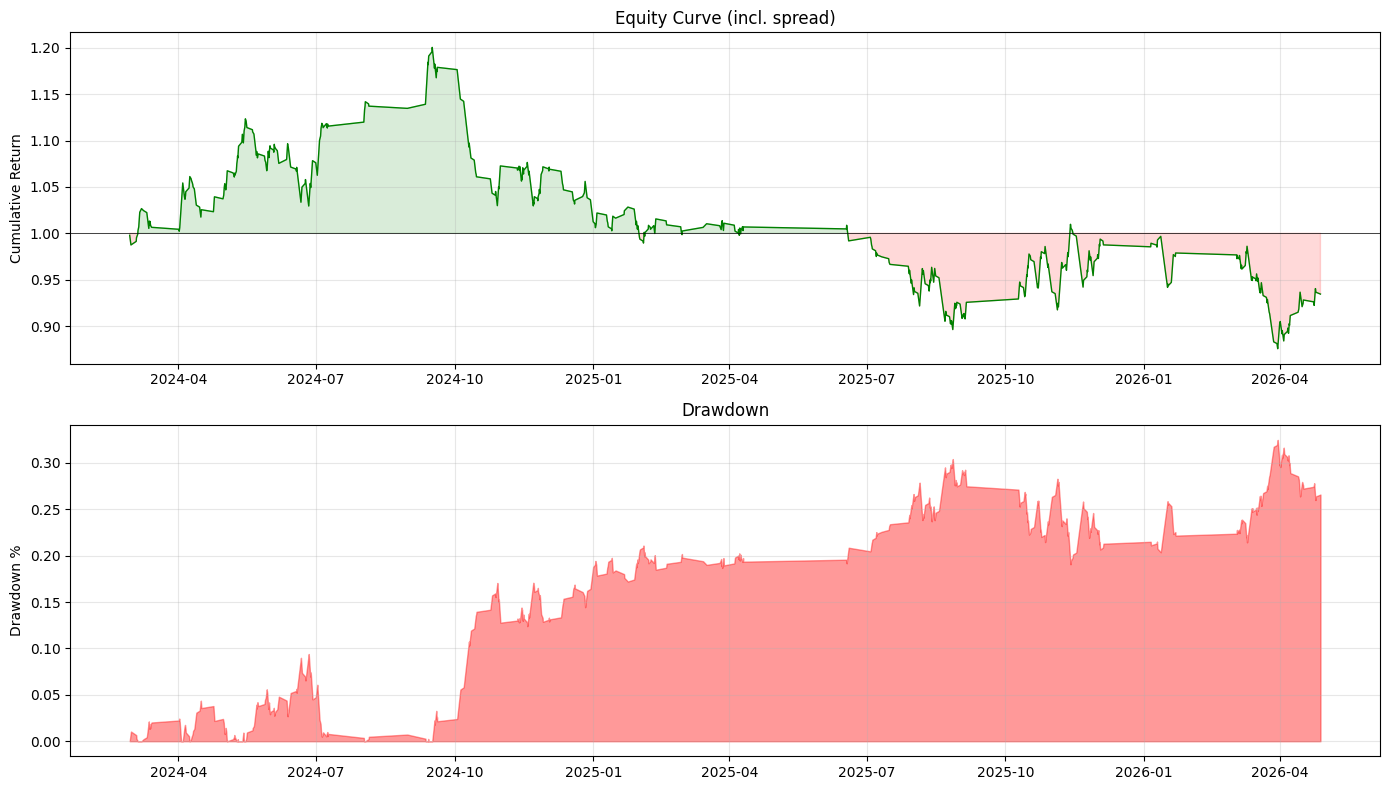

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Equity curve
axes[0].plot(bt['time'], bt['cumulative'], color='green', linewidth=1)
axes[0].fill_between(bt['time'], 1, bt['cumulative'], 
                     where=bt['cumulative'] >= 1, color='green', alpha=0.15)
axes[0].fill_between(bt['time'], 1, bt['cumulative'],
                     where=bt['cumulative'] < 1, color='red', alpha=0.15)
axes[0].axhline(y=1, color='black', linewidth=0.5)
axes[0].set_title('Equity Curve (incl. spread)')
axes[0].set_ylabel('Cumulative Return')
axes[0].grid(alpha=0.3)

# Drawdown
axes[1].fill_between(bt['time'], 0, bt['cumulative'].cummax() - bt['cumulative'],
                     color='red', alpha=0.4)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown %')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

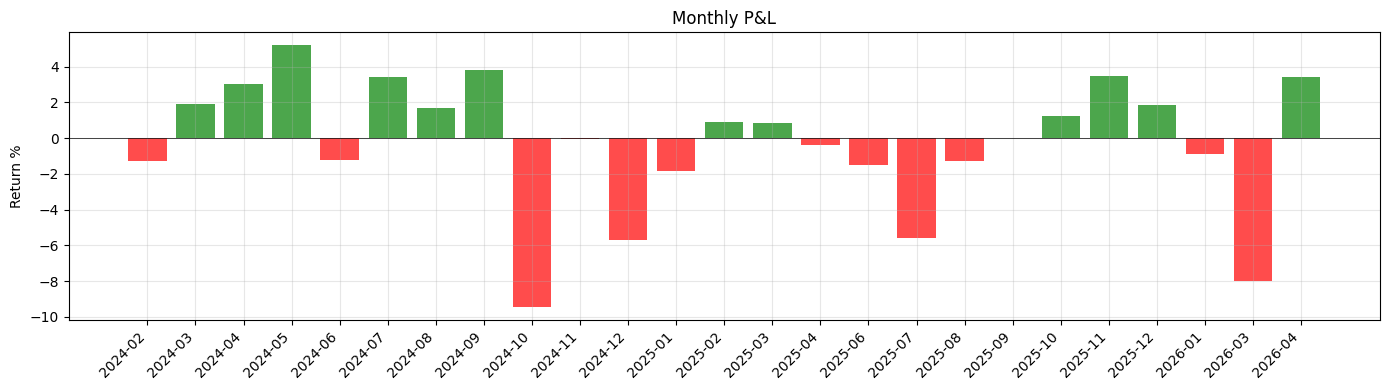

In [7]:
# Monthly returns
bt['month'] = pd.to_datetime(bt['time']).dt.to_period('M')
monthly = bt.groupby('month')['pnl'].sum() * 100

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['green' if v >= 0 else 'red' for v in monthly.values]
ax.bar(range(len(monthly)), monthly.values, color=colors, alpha=0.7)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels([str(m) for m in monthly.index], rotation=45, ha='right')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Monthly P&L')
ax.set_ylabel('Return %')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()